# An implementation of Multi-Task Learning using convolutional neural networks.

## Introduction:
Multi-Task Learning is a machine learning technique where you try to use one large model to predict 2 different outputs where the feature space is very similar.  This allows the model to "Share Information" within one another so that instead of having 2 independent predictions.  You create 2 predcitions that learn from eachother.

In this case study, we want to predict 2 different values: a categorical value **classifying* the time frame that a customer will purchase a ticket, as well as an explicitely prediction of how many days in advance the customer will purchase a ticket. 

# Build Network Architecture

## Imports

In [52]:
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader 
import dotenv as de

import numpy as np
import pandas as pd 
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold

#from sklearn.linear_model import LinearRegression, Lasso NOTE: Not used in current single model (Uncomment to implement and train)
#from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor NOTE: Not used in current single model (Uncomment to implement and train)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, r2_score, mean_squared_error,
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Class 1: Dataset Prep
A key step in dataset prep is to properly convert all of the columns into torch tensors for preparation for the archetecture. The constructor acomplishes the following tasks
- Rescale numeric columns using standard scaler
- Encode categorical columns using LabelEncoder()
- convert label vectors to torch tensors. 

In [53]:
class TicketDataset(Dataset):
    def __init__(
        self, df, numeric_cols, categorical_cols,
        reg_target, clf_target, scalar=None,
        encoders=None, clf_encoder=None, fit=True
    ):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols

        num_data = df[numeric_cols].to_numpy(dtype=np.float32)

        if fit:
            self.scalar = StandardScaler()
            num_data = self.scalar.fit_transform(num_data)
        else:
            self.scalar = scalar
            num_data = self.scalar.transform(num_data)

        self.num_data = torch.tensor(num_data, dtype=torch.float32)

        self.encoders = encoders if encoders is not None else {}
        cat_encoded = []

        for col in categorical_cols:
            if fit:
                encoder = LabelEncoder()
                encoded = encoder.fit_transform(df[col].astype(str))
                self.encoders[col] = encoder
            else:
                encoder = self.encoders[col]
                encoded = df[col].astype(str).map(
                    lambda value: (
                        encoder.transform([value])[0]
                        if value in encoder.classes_ else 0
                    )
                ).to_numpy()

            cat_encoded.append(encoded)

        # --- FIX: guard the empty case ---
        if categorical_cols:
            self.cat_data = torch.tensor(
                np.stack(cat_encoded, axis=1), dtype=torch.long
            )
        else:
            self.cat_data = torch.empty((len(df), 0), dtype=torch.long)

        if fit:
            self.clf_encoder = LabelEncoder()
            clf_encoded = self.clf_encoder.fit_transform(
                df[clf_target].astype(str)
            )
        else:
            self.clf_encoder = clf_encoder
            clf_encoded = self.clf_encoder.transform(
                df[clf_target].astype(str)
            )

        self.reg_y = torch.tensor(
            df[reg_target].to_numpy(dtype=np.float32)
        )
        self.clf_y = torch.tensor(clf_encoded, dtype=torch.long)

    def __len__(self):
        return len(self.reg_y)

    def __getitem__(self, index):
        return (
            self.num_data[index],
            self.cat_data[index],
            self.reg_y[index],
            self.clf_y[index],
        )

## Class 2 & 3: Multi-Task Network & Uncertainty Weight
The key hurdle that Multi-Task Learning faces compared to traditional modeling approaches is that we require a unified loss function that encompases both regression and classfication.  I.e. our "loss function" will be a weighted average between the 2 
$$
    Loss = \omega_1 * (Regression Loss) + \omega_2 * (Classification Loss)
$$
Each sub problem will have loss function
- Regression Loss -> Smooth L1 - Loss
- Classification Loss -> Categorical Cross Entropy

During training these weights will dynamically update using the UncertaintyWeightedLoss class.


The network follows a simple feed forward MLP 

(Input: Feature Vectors) --> (Layer 1: Linear, ReLU, Dropout) --> (Layer 2: Liner, ReLU, Dropout)

--(Split 1: Regression)--> (Layer 3-1: Linear, RelU, Linear) --> (Output: Regression Variable)

--(Split 2: Classification)--> (Layer 3-1: Linear, RelU, Linear) --> (Output (3-nodes): Classification Variable)


The first 2 layers are the "trunk" of the tree, by varying the trunk_dims parameter below I can experiment with the number of layers / number of nodes.



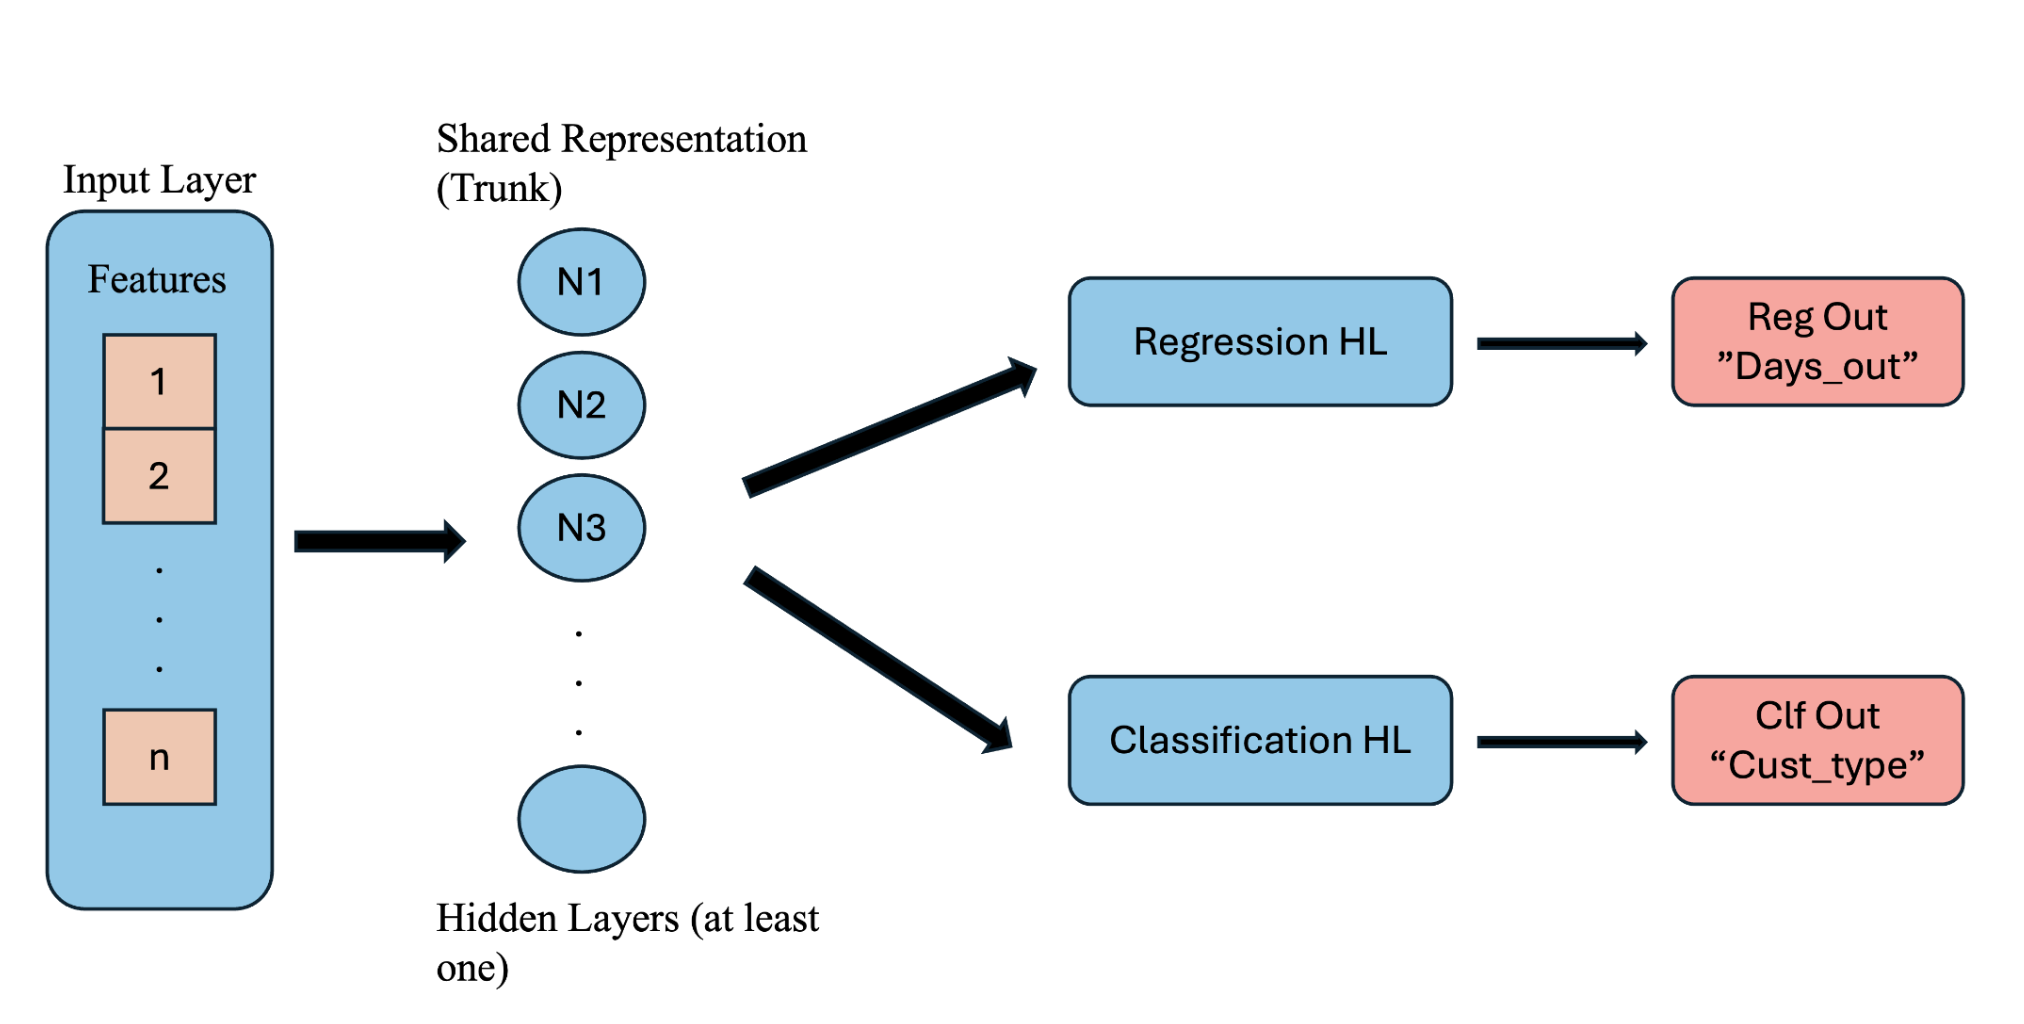

In [54]:
class MultiTaskNet(nn.Module):
    def __init__(
            self,
            num_numeric,
            cat_cardinalities,
            n_classes=3,
            trunk_dims=(64,32),
            emb_dropout=0.1,
            trunk_dropout=0.2
    ):

        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(card, min(50, (card + 1) // 2))
            for card in cat_cardinalities 
        ])
        emb_total = sum(min(50, (c + 1) // 2) for c in cat_cardinalities)
        self.emb_dropout = nn.Dropout(emb_dropout)

        input_dim = num_numeric + emb_total 

        trunk_layers = []
        prev = input_dim
        for dim in trunk_dims:
            trunk_layers += [
                nn.Linear(prev, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(trunk_dropout)
            ]
            prev=dim 

        self.trunk = nn.Sequential(*trunk_layers)
        trunk_out = prev

        # --- Task Heads --- 
        self.reg_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, 1) 
        )
        self.clf_head = nn.Sequential(
            nn.Linear(trunk_out, trunk_out // 2), nn.ReLU(),
            nn.Linear(trunk_out // 2, n_classes)
        )

    def forward(self, x_num, x_cat):
        if len(self.embeddings) > 0:
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x_cat_emb = self.emb_dropout(torch.cat(embs, dim=1))
            x = torch.cat([x_num, x_cat_emb], dim = 1)
        else:
            x = x_num 

        shared = self.trunk(x)
        reg_out = self.reg_head(shared).squeeze(-1)
        clf_logits = self.clf_head(shared)
        return reg_out, clf_logits


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.log_var_reg = nn.Parameter(torch.zeros(1))
        self.log_var_clf = nn.Parameter(torch.zeros(1))

    def forward(self, reg_pred, reg_true, clf_logits, clf_true):
        reg_loss = F.smooth_l1_loss(reg_pred, reg_true)
        clf_loss = F.cross_entropy(clf_logits, clf_true)

        loss = (
            torch.exp(-self.log_var_reg) * reg_loss + self.log_var_reg
            + torch.exp(-self.log_var_clf) * clf_loss + self.log_var_clf
        )
        return loss.squeeze(), reg_loss.item(), clf_loss.item()

### Train and Evaluation functions

In [55]:
def train(model, loss_fn, train_loader, val_loader, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(loss_fn.parameters()), lr=lr
    )

    device = 'cuda' if torch.cuda.is_available() else 'cpu' 
    model.to(device); loss_fn.to(device)

    for epoch in range(epochs):
        model.train()
        for x_num, x_cat, reg_y, clf_y in train_loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            reg_y, clf_y = reg_y.to(device), clf_y.to(device)

            optimizer.zero_grad()
            reg_pred, clf_logits = model(x_num, x_cat)
            loss, r_loss, c_loss = loss_fn(reg_pred, reg_y, clf_logits, clf_y)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_mae, val_acc, n = 0, 0, 0
        with torch.no_grad():
            for x_num, x_cat, reg_y, clf_y in val_loader:
                x_num, x_cat = x_num.to(device), x_cat.to(device)
                reg_y, clf_y = reg_y.to(device), clf_y.to(device)
                reg_pred, clf_logits = model(x_num, x_cat)
                val_mae += (reg_pred - reg_y).abs().sum().item()
                val_acc += (clf_logits.argmax(1) == clf_y).sum().item()
                n += len(reg_y)
        print(f"Epoch {epoch+1:3d} | reg_loss {r_loss:.3f} "
            f"clf_loss {c_loss:.3f} | val log-MAE {val_mae/n:.3f} "
            f"val Acc {val_acc/n:.3f}")





# ----------------------- Evaluation functions ----------------------
@torch.no_grad() #Loader loads the test data through the model and returns predictions.
def collect_predictions(model, loader, device, multitask=True):
    model.eval()
    reg_preds, reg_trues, clf_preds, clf_trues = [], [], [], []
    for x_num, x_cat, reg_y, clf_y in loader:
        x_num, x_cat = x_num.to(device), x_cat.to(device)
        reg_out, clf_logits = model(x_num, x_cat)
        reg_preds.append(reg_out.cpu().numpy())
        clf_preds.append(clf_logits.argmax(1).cpu().numpy())
        reg_trues.append(reg_y.numpy())
        clf_trues.append(clf_y.numpy())

    reg_pred = np.concatenate(reg_preds)
    reg_true = np.concatenate(reg_trues)


    return (reg_pred, reg_true,
            np.concatenate(clf_preds), np.concatenate(clf_trues))

def report_metrics(reg_pred, reg_true, clf_pred, clf_true, label=""): #Returns a collection of metrics. 
    mae = mean_absolute_error(reg_true, reg_pred)
    r2 = r2_score(reg_true, reg_pred)
    rmse = np.sqrt(mean_squared_error(reg_true, reg_pred))

    acc = accuracy_score(clf_true, clf_pred)
    f1 = f1_score(clf_true, clf_pred, average='macro')

    #print(f"===== {label} =====") NOTE: Prints were used during initial testing: not used because of k-fold cv.
    #print(f"  Regression   | MAE: {mae:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}")
    #print(f"  Classification   | Acc: {acc:.3f}  Macro-F1: {f1:.3f}")
    return {'mae' : mae, 'rmse' : rmse, 'R2' : r2, 'acc' : acc, 'f1' : f1}

# Network Training

## Build Dataset
This cell loads the excel file from my local directory and provides 

In [56]:
DATASET_NAME = de.get_key(".env", "DATASET_NAME")

data = pd.read_excel(f"data/{DATASET_NAME}", sheet_name = [1,2]) #Load in the 2nd and 3rd sheets of the excel file (all other sheets contain metadata and are not relevant)
DATA_ORIGINAL = pd.concat([data[1], data[2]], axis=0, ignore_index=True)
def preprocess_dataframe(df_orig):
    df = df_orig.copy() #Copy the original dataset

    df['Fan_Mailing_List'] = df['Fan_Mailing_List'].map({"Yes" : 1, "No" : 0}).astype(bool)
    df['Seat_Is_Upper'] = df['Seat_Location'].map({"Upper" : 1, "Lower" : 0}).astype(bool)

    df['Days_Before_Game'] = df['Days_Before_Game'].astype("float64")

    return df 

DATA = preprocess_dataframe(DATA_ORIGINAL)

# ----------------- Change to test different features -----------------------
numeric_cols = ['Num_Tickets_Purchased', 'Age', 'Ticket_Price', 'Seat_Is_Upper', 'Fan_Mailing_List'] #Input numeric features 
categorical_cols = [] #Input categorical features

# --- Labels --- 
reg_label='Days_Before_Game' #Regression Label
clf_label = 'Customer_Type' #Categorical Label

# ----------------------------------------------------------------------------


X = DATA[numeric_cols + categorical_cols]
y_reg = DATA[reg_label]
y_clf = DATA[clf_label]


## Apply K-Fold cross validation and train each individual split
- Train the Multi-Task Model
- Train 2 individual models
    - regression: RandomForestRegressor()
    - classification: RandomForestClassifier()

In [57]:
# ----- Training Parameters (Safe to Change) ----
num_splits = 10
epochs = 50 #Number of training epochs for each fold.

trunk_dims = (64,32) 
# Number of elements in the tuple coresponds to the number of layers in the trunk. (., ., .) --> 3 layers
# The number in each position represents the number of nodes in that layer
# Ex: (128, 64, 32) --> 3 Layers, each with 128, 64, and 32 nodes respectively.
# NOTE: Too many layers or too many nodes may lead to overfitting.  Alternatively too few will lead to underfitting.

# -----------------------------------------------

In [62]:
skf = StratifiedKFold(n_splits=num_splits, random_state=42, shuffle=True)

fold_scores = []
confusion_matricies = []
resid_plots = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_clf)):
    print(f"======== Training Fold {fold} =========")
    X_test = X.iloc[test_idx]
    y_reg_test = y_reg.iloc[test_idx]
    y_clf_test = y_clf.iloc[test_idx]

    #Split training set into an 85, 15 train test split.
    (
        X_train, X_val, 
        y_reg_train, y_reg_val, y_clf_train, y_clf_val
    ) = train_test_split(X.iloc[train_idx], y_reg.iloc[train_idx], y_clf.iloc[train_idx], test_size=0.15)

    train_fold = X_train.copy()
    train_fold[reg_label] = y_reg_train.to_numpy()
    train_fold[clf_label] = y_clf_train.to_numpy()

    val_fold = X_val.copy()
    val_fold[reg_label] = y_reg_val.to_numpy()
    val_fold[clf_label] = y_clf_val.to_numpy()

    test_fold = X_test.copy()
    test_fold[reg_label] = y_reg_test.to_numpy()
    test_fold[clf_label] = y_clf_test.to_numpy()

    train_ds_fold = TicketDataset(
        train_fold, numeric_cols, categorical_cols,
        reg_label, clf_label, fit=True
    )

    val_ds_fold = TicketDataset(
        val_fold, numeric_cols, categorical_cols,
        reg_label, clf_label,
        scalar=train_ds_fold.scalar,
        encoders=train_ds_fold.encoders,
        clf_encoder=train_ds_fold.clf_encoder,
        fit=False
    )

    test_ds_fold = TicketDataset(
        test_fold, numeric_cols, categorical_cols,
        reg_label, clf_label,
        scalar=train_ds_fold.scalar,
        encoders=train_ds_fold.encoders,
        clf_encoder=train_ds_fold.clf_encoder,
        fit=False
    )

    model = MultiTaskNet(
        num_numeric=len(numeric_cols),
        cat_cardinalities=[train_fold[col].nunique() for col in categorical_cols],
        n_classes=len(train_ds_fold.clf_encoder.classes_),
        trunk_dims=trunk_dims
    )
    loss_fn = UncertaintyWeightedLoss()

    train(
        model,
        loss_fn,
        DataLoader(
            train_ds_fold,
            batch_size=64,
            shuffle=True,
            drop_last=True
        ),
        DataLoader(
            val_ds_fold,
            batch_size=256,
            shuffle=False
        ),
        epochs=epochs
    )

    fold_device = 'cuda' if torch.cuda.is_available() else 'cpu' 
    fold_loader = DataLoader(test_ds_fold, batch_size=256)

    nn_reg_pred, nn_reg_true, nn_clf_pred, nn_clf_true = (
        collect_predictions(model, fold_loader, fold_device)
    )

    confusion_matricies.append(confusion_matrix(nn_clf_true, nn_clf_pred)) #Keep track of confution matrices for each split (the best fold will be displayed below)
    resid_plots.append((nn_reg_true, nn_reg_pred)) #Same principle with the regression output. 


    nn_scores = report_metrics(
        nn_reg_pred, nn_reg_true,
        nn_clf_pred, nn_clf_true,
        label=f"Neural Network Fold {fold + 1}"
    )


    # ------ Train Single Model Alternative ---------
    rf_reg = RandomForestRegressor(
        n_estimators=200, random_state=47
    )
    rf_clf = RandomForestClassifier(
        n_estimators=200, random_state=47
    )

    rf_reg.fit(X_train, y_reg_train)
    rf_clf.fit(X_train, y_clf_train)

    rf_reg_pred = rf_reg.predict(X_test)
    rf_clf_pred = rf_clf.predict(X_test)

    rf_scores = report_metrics(
        rf_reg_pred, y_reg_test,
        rf_clf_pred, y_clf_test,
        label=f"Random Forest Fold {fold + 1}"
    )
    # ------------------------------------------------

    fold_scores.append({
        'fold': fold + 1,
        'nn_mae': nn_scores['mae'],
        'nn_rmse': nn_scores['rmse'],
        'nn_r2': nn_scores['R2'],
        'nn_accuracy': nn_scores['acc'],
        'nn_f1': nn_scores['f1'],
        'rf_mae': rf_scores['mae'],
        'rf_rmse': rf_scores['rmse'],
        'rf_r2': rf_scores['R2'],
        'rf_accuracy': rf_scores['acc'],
        'rf_f1': rf_scores['f1'],
        'nn_acc_wins' : nn_scores['acc'] >= rf_scores['acc']
    })

    print()

cv_results_df = pd.DataFrame(fold_scores)
display(cv_results_df)
display(cv_results_df.drop(columns='fold').mean().to_frame('mean').T)

======== Training Fold 0 =========
Epoch   1 | reg_loss 8.888 clf_loss 0.957 | val log-MAE 11.001 val Acc 0.456
Epoch   2 | reg_loss 10.263 clf_loss 0.904 | val log-MAE 10.753 val Acc 0.581
Epoch   3 | reg_loss 9.875 clf_loss 0.845 | val log-MAE 10.466 val Acc 0.603
Epoch   4 | reg_loss 8.840 clf_loss 0.703 | val log-MAE 10.194 val Acc 0.603
Epoch   5 | reg_loss 8.370 clf_loss 0.744 | val log-MAE 9.843 val Acc 0.618
Epoch   6 | reg_loss 9.721 clf_loss 0.791 | val log-MAE 9.408 val Acc 0.618
Epoch   7 | reg_loss 10.086 clf_loss 0.660 | val log-MAE 8.784 val Acc 0.676
Epoch   8 | reg_loss 8.881 clf_loss 0.677 | val log-MAE 7.964 val Acc 0.699
Epoch   9 | reg_loss 6.511 clf_loss 0.639 | val log-MAE 7.074 val Acc 0.699
Epoch  10 | reg_loss 7.249 clf_loss 0.728 | val log-MAE 6.174 val Acc 0.721
Epoch  11 | reg_loss 5.779 clf_loss 0.534 | val log-MAE 5.488 val Acc 0.728
Epoch  12 | reg_loss 5.361 clf_loss 0.635 | val log-MAE 4.986 val Acc 0.743
Epoch  13 | reg_loss 5.198 clf_loss 0.666 | val

,fold,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1,nn_acc_wins
0,1,4.316326,6.049156,0.596296,0.683168,0.662246,4.931188,6.897797,0.475078,0.673267,0.656518,True
1,2,5.014500,6.905139,0.600527,0.782178,0.768948,5.235099,6.998859,0.589610,0.742574,0.733766,True
2,3,4.578171,6.590261,0.578806,0.821782,0.813101,4.701485,6.417247,0.600630,0.792079,0.786881,True
3,4,3.423984,4.932611,0.738818,0.841584,0.838869,4.024059,5.669908,0.654903,0.762376,0.762428,True
4,5,5.223713,7.462527,0.468488,0.732673,0.730182,5.635990,8.001411,0.388953,0.683168,0.685741,True
5,6,4.416443,6.451992,0.596383,0.740000,0.741555,4.706800,6.567460,0.581807,0.720000,0.720468,True
6,7,4.574994,6.377208,0.529734,0.720000,0.719587,4.869800,6.536037,0.506018,0.690000,0.683489,True
7,8,3.859786,5.291556,0.716358,0.830000,0.820721,4.458550,5.995073,0.635923,0.800000,0.793675,True
8,9,4.789858,6.997931,0.552047,0.840000,0.831545,5.261600,7.383377,0.501342,0.720000,0.710944,True
9,10,4.293003,6.012597,0.635564,0.780000,0.765410,4.524750,5.970761,0.640617,0.740000,0.726376,True


,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1,nn_acc_wins
mean,4.449078,6.307097,0.601302,0.777139,0.769216,4.834932,6.643793,0.557488,0.732347,0.726029,1.0


## Find Best Fold
I want to minimize the number of emails that are sent out, if my goal is to primality use the category predicted to drive email.  So I will choose the split that has the highest accuracy.

In [69]:
#best_fold = cv_results_df[cv_results_df['nn_accuracy'] == cv_results_df['nn_accuracy'].max()]
best_folds = cv_results_df.sort_values(by='nn_accuracy', ascending=False)
display(best_folds.iloc[:3])
print(f"Number of folds nn beats rf in acc: {int(cv_results_df[cv_results_df['nn_acc_wins'] == True]['nn_acc_wins'].count())}")

,fold,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1,nn_acc_wins
3,4,3.423984,4.932611,0.738818,0.841584,0.838869,4.024059,5.669908,0.654903,0.762376,0.762428,True
8,9,4.789858,6.997931,0.552047,0.840000,0.831545,5.261600,7.383377,0.501342,0.720000,0.710944,True
7,8,3.859786,5.291556,0.716358,0.830000,0.820721,4.458550,5.995073,0.635923,0.800000,0.793675,True


Number of folds nn beats rf: 10


In [77]:
# Best accuracy from the single classifier model.T_destination
display(f"Highest accuracy achieved by Random Forest {cv_results_df['rf_accuracy'].max():0.4f}")
display(cv_results_df.sort_values(by='rf_accuracy', ascending=False).head())

'Highest accuracy achieved by Random Forest 0.8000'

,fold,nn_mae,nn_rmse,nn_r2,nn_accuracy,nn_f1,rf_mae,rf_rmse,rf_r2,rf_accuracy,rf_f1,nn_acc_wins
7,8,3.859786,5.291556,0.716358,0.830000,0.820721,4.458550,5.995073,0.635923,0.800000,0.793675,True
2,3,4.578171,6.590261,0.578806,0.821782,0.813101,4.701485,6.417247,0.600630,0.792079,0.786881,True
3,4,3.423984,4.932611,0.738818,0.841584,0.838869,4.024059,5.669908,0.654903,0.762376,0.762428,True
1,2,5.014500,6.905139,0.600527,0.782178,0.768948,5.235099,6.998859,0.589610,0.742574,0.733766,True
9,10,4.293003,6.012597,0.635564,0.780000,0.765410,4.524750,5.970761,0.640617,0.740000,0.726376,True


# Diagnostics

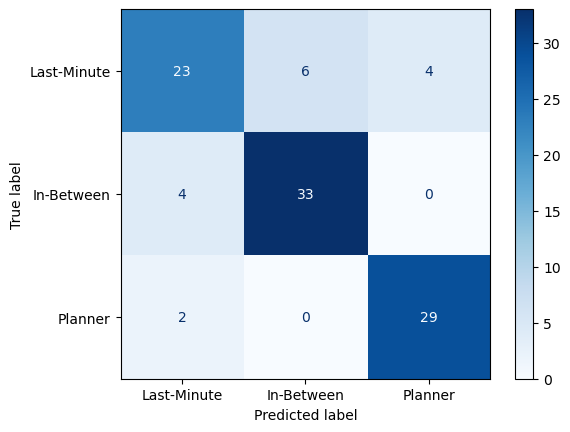

In [64]:
best_matrix = confusion_matricies[int(best_folds['fold'].iloc[0] - 1)]
disp = ConfusionMatrixDisplay(confusion_matrix=best_matrix, display_labels=list(DATA[clf_label].unique()))
disp.plot(cmap=plt.cm.Blues)

### Regression Analysis

Text(0, 0.5, 'Residual')

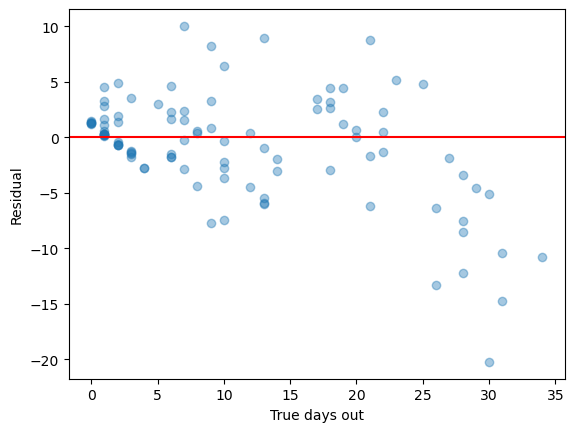

In [65]:
best_reg = resid_plots[int(best_folds['fold'].iloc[0] - 1)]
r_true, r_pred = best_reg[0], best_reg[1]
plt.scatter(r_true, r_pred - r_true, alpha=0.4)
plt.axhline(0, color='r')
plt.xlabel('True days out')
plt.ylabel('Residual')

Initial model reports sytematic bias that will try to account for by log-transforming into the dataset.